<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
# !pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

In [2]:
# !pip install --ignore-installed huggingface-hub==0.20.3

In [3]:
# # После перезапуска ядра
# !pip uninstall huggingface-hub -y
# !pip install huggingface-hub==0.20.3

# # Проверка версии
# import huggingface_hub
# print(f"Installed version: {huggingface_hub.__version__}")

In [4]:
# !pip install --upgrade sentence-transformers

In [5]:
# !pip install pacmap

In [6]:
# !pip install -U bitsandbytes>=0.46.1

In [7]:
# !pip uninstall langchain-community -y
# !pip install langchain-community
# !pip install --upgrade sentence-transformers

In [8]:
# !pip install ragatouille

In [9]:
import warnings

# from huggingface_hub import hf_hub_download
# import huggingface_hub

# huggingface_hub.cached_download = hf_hub_download

warnings.filterwarnings('ignore')

import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain.docstore.document import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
# from ragatouille import RAGPretrainedModel
import os

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки
from langchain.text_splitter import RecursiveCharacterTextSplitter

from sklearn.feature_extraction.text import TfidfVectorizer
import re
import string
import nltk
import pymorphy2
from nltk.corpus import stopwords
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from transformers import Pipeline

# pd.set_option("display.max_colwidth", None)

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

Используется устройство: cuda


In [11]:
os.makedirs('content', exist_ok=True)
os.makedirs('models', exist_ok=True)

In [12]:
# !nvidia-smi

## Загрузка данных (4 балла)

In [13]:
# url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
# output = 'file.csv'

# gdown.download(url, output, quiet=False)

# data = pd.read_csv('file.csv')

In [14]:
# Загрузка данных

file_id = '1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'content/file.csv'

if not os.path.exists(output):
    gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=d880b02a-18a1-4223-904c-549d55d27e63
To: c:\Projects\ds-stepik\deep_learning_2_2026\08_chatgpt_instruction_tuning_RAG\content\file.csv
100%|██████████| 672M/672M [03:34<00:00, 3.13MB/s] 


In [15]:
data = pd.read_csv(output).drop('Unnamed: 0', axis=1, errors='ignore')

In [16]:
data.head()

,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [17]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [18]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

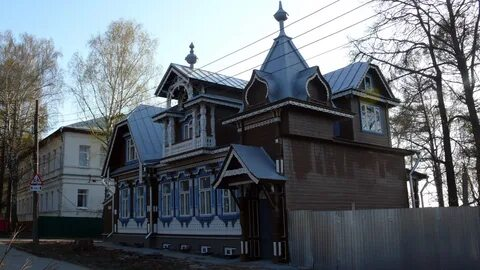

In [19]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - самое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

Проверим датасет на предмет пропусков

In [20]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         14634 non-null  str    
 1   WikiData     12078 non-null  str    
 2   City         14634 non-null  str    
 3   Lon          14634 non-null  float64
 4   Lat          14634 non-null  float64
 5   description  12078 non-null  str    
 6   image        14634 non-null  str    
 7   en_txt       14634 non-null  str    
dtypes: float64(2), str(6)
memory usage: 641.0 MB


In [21]:
data.isna().sum()

Name              0
WikiData       2556
City              0
Lon               0
Lat               0
description    2556
image             0
en_txt            0
dtype: int64

Удалим строки с пропусками в WikiData и проверим датасет еще раз на предмет пропусков

In [22]:
data = data.dropna(subset=['WikiData'])

data.isna().sum()

Name           0
WikiData       0
City           0
Lon            0
Lat            0
description    0
image          0
en_txt         0
dtype: int64

In [23]:
# sorted(data['WikiData'].unique(), reverse=True)
# sorted(data['description'].unique(), reverse=False)
sorted(data['en_txt'].unique(), reverse=True)

['прррмомоннннннннннн',
 'yellow house with a black roof and a white fence',
 'yellow flowers in front of a brick building with a clock tower',
 'yellow church with blue domes and a clock tower in a city',
 'yellow church with a golden dome on a sunny day',
 'yellow church with a golden dome on a cloudy day',
 'yellow church with a golden dome and a steeple on a street corner',
 'yellow church with a golden dome and a cross on top',
 'yellow church with a blue dome and a cross on the front',
 'yellow bus parked in front of a large yellow building with a green roof',
 'yellow building with white trim and windows on a sunny day',
 'yellow building with white trim and windows on a street corner',
 'yellow building with white trim and windows in winter time',
 'yellow building with white trim and windows in snow covered area',
 'yellow building with white trim and windows and a sign on the front',
 'yellow building with white trim and windows',
 'yellow building with white trim and columns

In [24]:
# В колонке 'en_txt' замечено значение 'прррмомоннннннннннн', заменим его на моду

mask = data['en_txt'] == 'прррмомоннннннннннн'
name_field = data[mask]['Name'].iloc[0]
print(name_field)

mode_value = data[data['Name'] == name_field]['en_txt'].mode()[0]
print(mode_value)

data.loc[mask, 'en_txt'] = mode_value

Ярославский дворец молодёжи
there is a building with a sign on the top of it


In [25]:
data[data['en_txt'] == 'there is a building with a sign on the top of it']

,Name,WikiData,City,Lon,Lat,description,image,en_txt
853,№18 Фотографический музей «Дом Метенкова»,Q4165339,Екатеринбург,60.610767,56.841969,музей в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign on the top of it
1029,Дом Метенкова,Q4165339,Екатеринбург,60.610954,56.841991,музей в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign on the top of it
14353,Ярославский дворец молодёжи,Q4538877,Ярославль,39.867222,57.636250,Ярославский дворец молодёжи,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign on the top of it
14364,Ярославский дворец молодёжи,Q4538877,Ярославль,39.867222,57.636250,Ярославский дворец молодёжи,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign on the top of it
14365,Ярославский дворец молодёжи,Q4538877,Ярославль,39.867222,57.636250,Ярославский дворец молодёжи,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign on the top of it


Теперь используем алгоритм TF-IDF (Term Frequency-Inverse Document Frequency)

In [26]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer

def tfidf_text_cleanup(df):
    """
    Очистка текстовых данных от мусора с помощью TF-IDF
    """

    df_temp = df.copy()
    
    # Объединение текстовых полей с информацией о локации
    df_temp['full_text'] = (
        df_temp['Name'].fillna('').astype(str) + ' ' +
        df_temp['description'].fillna('').astype(str) + ' ' +
        df_temp['en_txt'].fillna('').astype(str)
    )
    
    # Предобработка текста
    def clean_text(text):
        text = str(text).lower()                    # приводим к нижнему регистру
        text = re.sub(r'[^a-zа-я\s]', '', text)     # оставляем только буквы и пробелы
        text = re.sub(r'\s+', ' ', text)            # убираем лишние пробелы
        return text.strip()
    
    df_temp['clean_text'] = df_temp['full_text'].apply(clean_text)
    
    # Фильстрация слабоинформативных текстов
    df_temp = df_temp[df_temp['clean_text'].str.len() > 10]
    
    # TF-IDF
    vectorizer = TfidfVectorizer(
        max_features=1000,
        min_df=2,
        max_df=0.9
    )

    tfidf_matrix = vectorizer.fit_transform(df_temp['clean_text'])
    
    # Поиск самых редких слов
    feature_Names = vectorizer.get_feature_names_out()
    word_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()
    
    # Сортировка по редкости
    rare_words = sorted(zip(feature_Names, word_scores), key=lambda x: x[1])
    
    # Отбор выбросов по порогу в garbage_threshold по редкости
    garbage_threshold = 30
    garbage_words = [word for word, score in rare_words[:garbage_threshold]]
    garbage_pattern = '|'.join(garbage_words)

    print(f'Потенциальные выбросы: {garbage_words}')
    
    # Удаление выбросов
    mask = df_temp['clean_text'].str.contains(garbage_pattern, regex=True, na=False)
    garbage_rows = df_temp[mask]
    df_cleaned = df_temp[~mask]
    
    print(f'\nУдалено выбросов: {len(garbage_rows)}')
    print(f'Осталось после очистки: {len(df_cleaned)}')
        
    # Удаление дубликатов (оставляем самое длинное описание)
    df_cleaned['text_length'] = df_cleaned['clean_text'].str.len()
    df_cleaned = df_cleaned.sort_values('text_length', ascending=False)
    df_cleaned = df_cleaned.drop_duplicates(subset=['Name', 'City'], keep='first')
    df_cleaned = df_cleaned.drop(columns=['text_length'])
    
    print(f'\nОсталось после удаления дубликатов: {len(df_cleaned)}')
    
    
    print(f'\nСохранено {len(df_cleaned)} / {len(df)} записей')
    
    return df_cleaned

In [27]:
df_analysis = tfidf_text_cleanup(data)

Потенциальные выбросы: ['болгарии', 'видную', 'выдающегося', 'генерала', 'деятельности', 'жизни', 'ига', 'инфантерии', 'освобождении', 'посвящнный', 'роль', 'столетовых', 'сыгравшего', 'турецкого', 'учногофизика', 'dining', 'women', 'cloth', 'cases', 'teddy', 'вгувт', 'государственной', 'готовящее', 'которая', 'называется', 'нижегородское', 'образования', 'профессионального', 'речное', 'сейчас']

Удалено выбросов: 147
Осталось после очистки: 11931

Осталось после удаления дубликатов: 318

Сохранено 318 / 12078 записей


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

Вместо RAGatouille из ragatouille буду использорвать альтернативу (CrossEncoderReranker)

In [28]:
df = df_analysis.copy()

In [29]:
# Создаем документы LangChain
documents = []

for idx, row in df.iterrows():
    # Формируем текст документа
    text_parts = []
    
    if pd.notna(row.get('Name')):
        text_parts.append(f"Название: {row['Name']}")
    
    if pd.notna(row.get('City')):
        text_parts.append(f"Город: {row['City']}")
    
    if pd.notna(row.get('description')):
        text_parts.append(f"Описание: {row['description']}")
    
    if pd.notna(row.get('en_txt')):
        text_parts.append(f"Английское описание: {row['en_txt']}")
    
    full_text = "\n".join(text_parts)
    
    # Создаем документ с метаданными
    doc = LangchainDocument(
        page_content=full_text,
        metadata={
            "name": row.get('Name', ''),
            "city": row.get('City', ''),
            "index": idx
        }
    )
    documents.append(doc)

print(f"Создано {len(documents)} документов")

Создано 318 документов


Разбиение на чанки

In [30]:
# Разделители
MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",        # Абзацы / Заголовки
    "\n\n",             # Абзацы
    "\n",               # Строки
    ". ",               # Предложения
    ", ",               # Части предложений
    " ",                # Слова
    "",                 # Символы
    "```\n",            # Закрывающие теги
    "\n\\*\\*\\*+\n",   # Разделитель ***
    "\n---+\n",         # Разделитель ---
    "\n___+\n",         # Разделитель ___
]

# Модель для эмбеддингов
EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-small"

In [31]:
def split_documents(
    chunk_size: int,
    knowledge_base: List[LangchainDocument],
    tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME,
) -> List[LangchainDocument]:
    """
    Разбиение документов на чанки с учетом токенизации
    """
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer,
        chunk_size=chunk_size,                  # Максимальное количество символов в чанке
        chunk_overlap=int(chunk_size / 10),     # Количество символов, которые будут перекрываться между чанками
        add_start_index=True,                   # Если "True", то включает начальный индекс чанка в метаданные
        strip_whitespace=True,                  # Если значение "True", то пробелы удаляются из начала и конца каждого документа
        separators=MARKDOWN_SEPARATORS,         # Разделители
    )
    
    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])
    
    # Удаление дубликатов
    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)
    
    return docs_processed_unique

In [32]:
# Разбиение на чанки размером chunk_size

chunk_size = 512
docs_chunked = split_documents(chunk_size, documents)

In [33]:
# Инициализация модели эмбеддингов

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True},  # Для косинусного сходства
)

C:\Users\pong\AppData\Local\Temp\ipykernel_3988\3901755238.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


In [34]:
# Создание векторной базы с косинусным расстоянием

vector_db = FAISS.from_documents(
    docs_chunked, 
    embedding_model, 
    distance_strategy=DistanceStrategy.COSINE
)

In [35]:
# Создание базового ретривера
base_retriever = vector_db.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 30}
)

# Использование CrossEncoderReranker для реранкинга
reranker_model = HuggingFaceCrossEncoder(
    model_name='cross-encoder/ms-marco-MiniLM-L-6-v2'
)

compressor = CrossEncoderReranker(
    model=reranker_model, 
    top_n=5  # Оставляем только 5 лучших документов
)

# Компрессированный ретривер с реранкингом
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=base_retriever
)

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [ ]:
# your code here

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

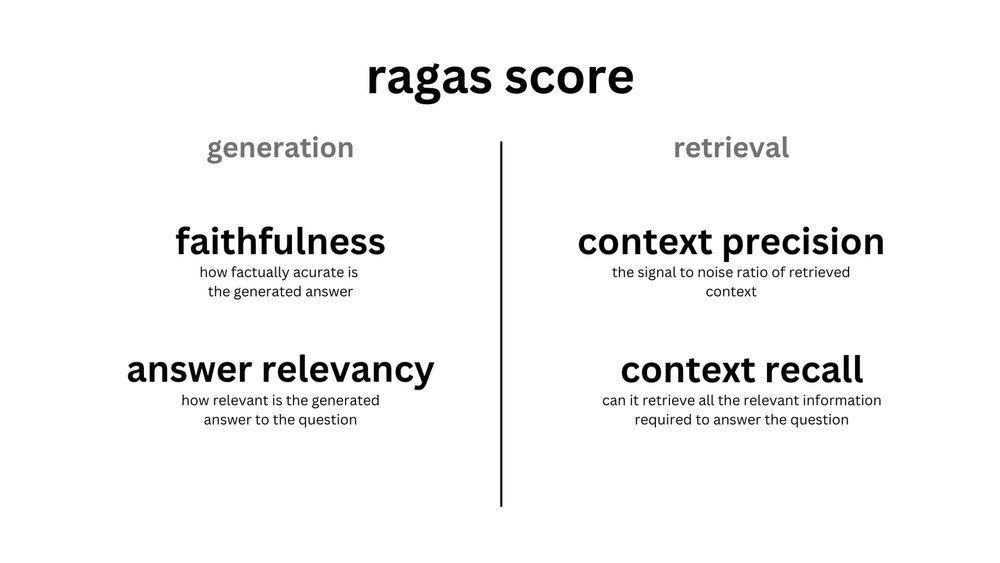

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
def data_preprocess(...):
  # your code here
  return ...

SyntaxError: invalid syntax (15133680.py, line 1)

In [ ]:
def answer_relevancy(...):
  # your code here
  return ...

# Протестируйте ваш RAG (3 балла)

In [ ]:
# your code here

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
# your code here

In [46]:
import warnings
warnings.filterwarnings('ignore')

import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List, Tuple, Dict, Any
from tqdm import tqdm
import os
import torch
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
import umap
import base64
from io import BytesIO
from PIL import Image
import random

# LangChain и связанные импорты
from langchain.docstore.document import Document as LangchainDocument
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

# Transformers для моделей
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer

# Настройка устройства
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

# Создание директорий
os.makedirs('content', exist_ok=True)
os.makedirs('models', exist_ok=True)

# ==============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ==============================================================================
file_id = '1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'content/file.csv'

if not os.path.exists(output):
    print("Загрузка данных...")
    gdown.download(id=file_id, output=output, quiet=False)

data = pd.read_csv(output).drop('Unnamed: 0', axis=1, errors='ignore')
print(f"Загружено {len(data)} записей")

# Проверка наличия пропусков
print(f"\nПропуски в данных:\n{data.isna().sum()}")

# Удаление строк с пропусками в WikiData
data = data.dropna(subset=['WikiData'])
print(f"После удаления пропусков: {len(data)} записей")

# Исправление аномального значения 'en_txt'
mask = data['en_txt'] == 'прррмомоннннннннннн'
if mask.any():
    name_field = data[mask]['Name'].iloc[0]
    mode_value = data[data['Name'] == name_field]['en_txt'].mode()[0]
    data.loc[mask, 'en_txt'] = mode_value
    print(f"Исправлено аномальное значение 'en_txt' для {name_field}")

# ==============================================================================
# 2. ОЧИСТКА ДАННЫХ С ПОМОЩЬЮ TF-IDF
# ==============================================================================
def tfidf_text_cleanup(df: pd.DataFrame, garbage_threshold: int = 30) -> pd.DataFrame:
    print("\n--- Очистка данных с помощью TF-IDF ---")
    df_temp = df.copy()
    
    df_temp['full_text'] = (
        df_temp['Name'].fillna('').astype(str) + ' ' +
        df_temp['description'].fillna('').astype(str) + ' ' +
        df_temp['en_txt'].fillna('').astype(str)
    )
    
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'[^a-zа-я\s]', '', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    df_temp['clean_text'] = df_temp['full_text'].apply(clean_text)
    df_temp = df_temp[df_temp['clean_text'].str.len() > 20]
    print(f"После фильтрации коротких текстов: {len(df_temp)} записей")
    
    vectorizer = TfidfVectorizer(max_features=1500, min_df=2, max_df=0.9, ngram_range=(1, 2))
    tfidf_matrix = vectorizer.fit_transform(df_temp['clean_text'])
    
    feature_names = vectorizer.get_feature_names_out()
    word_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()
    rare_words = sorted(zip(feature_names, word_scores), key=lambda x: x[1])
    garbage_words = [word for word, score in rare_words[:garbage_threshold]]
    garbage_pattern = '|'.join(re.escape(word) for word in garbage_words)
    
    print(f"Потенциальные выбросы: {garbage_words[:15]}...")
    
    mask = df_temp['clean_text'].str.contains(garbage_pattern, regex=True, na=False)
    df_cleaned = df_temp[~mask]
    print(f"Удалено строк с мусором: {mask.sum()}, осталось: {len(df_cleaned)}")
    
    df_cleaned['text_length'] = df_cleaned['clean_text'].str.len()
    df_cleaned = df_cleaned.sort_values('text_length', ascending=False)
    df_cleaned = df_cleaned.drop_duplicates(subset=['Name', 'City'], keep='first')
    df_cleaned = df_cleaned.drop(columns=['text_length'])
    
    print(f"Осталось после удаления дубликатов: {len(df_cleaned)}")
    return df_cleaned

data_cleaned = tfidf_text_cleanup(data)
print(f"\nОчищенные данные: {len(data_cleaned)} записей")

# ==============================================================================
# 3. ПОДГОТОВКА ДОКУМЕНТОВ И РАЗБИЕНИЕ НА ЧАНКИ
# ==============================================================================
print("\n--- Подготовка документов ---")
documents = []

for idx, row in data_cleaned.iterrows():
    text_parts = []
    if pd.notna(row.get('Name')):
        text_parts.append(f"Название: {row['Name']}")
    if pd.notna(row.get('City')):
        text_parts.append(f"Город: {row['City']}")
    if pd.notna(row.get('description')):
        text_parts.append(f"Описание: {row['description']}")
    if pd.notna(row.get('en_txt')):
        text_parts.append(f"Английское описание: {row['en_txt']}")
    
    full_text = "\n".join(text_parts)
    
    doc = LangchainDocument(
        page_content=full_text,
        metadata={
            "name": row.get('Name', ''),
            "city": row.get('City', ''),
            "description": row.get('description', ''),
            "index": idx
        }
    )
    documents.append(doc)

print(f"Создано {len(documents)} документов")

MARKDOWN_SEPARATORS = ["\n\n", "\n", ". ", ", ", " ", ""]
EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-small"

def split_documents(chunk_size: int, knowledge_base: List[LangchainDocument], tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME) -> List[LangchainDocument]:
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer, chunk_size=chunk_size, chunk_overlap=int(chunk_size / 10),
        add_start_index=True, strip_whitespace=True, separators=MARKDOWN_SEPARATORS,
    )
    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])
    
    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)
    return docs_processed_unique

chunk_size = 512
docs_chunked = split_documents(chunk_size, documents)
print(f"Создано {len(docs_chunked)} чанков")

# ==============================================================================
# 4. СОЗДАНИЕ ВЕКТОРНОЙ БАЗЫ ДАННЫХ
# ==============================================================================
print("\n--- Создание векторной базы данных ---")

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True},
)

vector_db = FAISS.from_documents(docs_chunked, embedding_model, distance_strategy=DistanceStrategy.COSINE)
print(f"Векторная база создана, размерность: {vector_db.index.d}")
print(f"Количество векторов: {vector_db.index.ntotal}")

# ==============================================================================
# 5. ОБНОВЛЕННАЯ ФУНКЦИЯ ИЗВЛЕЧЕНИЯ ГОРОДА (С ПАДЕЖАМИ)
# ==============================================================================

def extract_city_from_query(query: str, cities_list: List[str]) -> Optional[str]:
    """
    Улучшенное извлечение города из запроса с учетом падежей
    """
    query_lower = query.lower()
    
    # Словарь падежных окончаний для русских городов
    city_variations = {}
    
    for city in cities_list:
        if not isinstance(city, str) or pd.isna(city):
            continue
        city_lower = city.lower()
        
        # Сохраняем оригинал
        city_variations[city_lower] = city
        
        # Добавляем варианты с падежными окончаниями
        if city_lower.endswith('а'):
            city_variations[city_lower[:-1]] = city  # без окончания
            city_variations[city_lower[:-1] + 'е'] = city  # предложный падеж (в Екатеринбурге)
            city_variations[city_lower[:-1] + 'у'] = city  # дательный падеж
        elif city_lower.endswith('я'):
            city_variations[city_lower[:-1] + 'и'] = city  # в Казани
        elif city_lower.endswith('ь'):
            city_variations[city_lower[:-1] + 'е'] = city  # в Ярославле
        elif city_lower.endswith('ск'):
            city_variations[city_lower + 'е'] = city  # в Москве
            city_variations[city_lower + 'у'] = city
        elif city_lower.endswith('град'):
            city_variations[city_lower + 'е'] = city
            city_variations[city_lower[:-4] + 'городе'] = city
    
    # Поиск по всем вариациям
    for var, original_city in city_variations.items():
        if var in query_lower:
            print(f"  [DEBUG] Найден город '{original_city}' по вариации '{var}' в запросе")
            return original_city
    
    # Прямой поиск
    for city in cities_list:
        if not isinstance(city, str) or pd.isna(city):
            continue
        if city.lower() in query_lower:
            print(f"  [DEBUG] Найден город '{city}' прямым вхождением")
            return city
    
    print(f"  [DEBUG] Город не найден в запросе: '{query}'")
    return None


# ==============================================================================
# 6. УЛУЧШЕННАЯ RAG ФУНКЦИЯ С ГЕО-ФИЛЬТРАЦИЕЙ
# ==============================================================================

def rag_query_with_geo_filter(
    question: str, 
    top_k_initial: int = 30,
    top_k_final: int = 5,
    city_boost_weight: float = 0.4
) -> Tuple[str, List[Dict]]:
    """
    RAG запрос с улучшенной гео-фильтрацией
    """
    if not isinstance(question, str) or len(question.strip()) == 0:
        return 'Информация не найдена', []
    
    print(f"\n  [RAG] Обработка запроса: '{question[:80]}...'")
    
    # Получаем список всех городов из данных
    all_cities = data_cleaned['City'].dropna().unique().tolist()
    
    # Извлекаем целевой город из запроса
    target_city = extract_city_from_query(question, all_cities)
    
    # 1. Первичный поиск через ретривер с реранкингом
    try:
        docs = compression_retriever.invoke(question)
        print(f"  [RAG] Найдено {len(docs)} документов через ретривер")
    except Exception as e:
        print(f"  [RAG] Ошибка ретривера: {e}")
        docs = vector_db.similarity_search(question, k=top_k_initial)
        print(f"  [RAG] Использован fallback поиск, найдено {len(docs)} документов")
    
    # 2. Ранжирование с учетом города
    scored_docs = []
    
    for doc in docs:
        doc_city = doc.metadata.get('city', '')
        doc_name = doc.metadata.get('name', '')
        
        # Косинусное сходство (если есть в метаданных)
        base_score = 0.5
        
        # Городской бонус
        city_bonus = 0.0
        city_match = False
        
        if target_city and doc_city:
            # Сравнение с учетом регистра и возможных вариантов
            if target_city.lower() == doc_city.lower():
                city_bonus = city_boost_weight
                city_match = True
                print(f"  [RAG] Совпадение по городу! '{doc_city}' + бонус {city_bonus}")
        
        # Бонус за название в запросе
        name_bonus = 0.0
        if doc_name and doc_name.lower() in question.lower():
            name_bonus = 0.15
        
        final_score = base_score + city_bonus + name_bonus
        scored_docs.append((doc, final_score, city_match, doc_city, doc_name))
    
    # 3. Сортировка по финальному скору
    scored_docs.sort(key=lambda x: x[1], reverse=True)
    
    # 4. Если есть целевой город, поднимаем документы с совпадением наверх
    if target_city:
        matched_docs = [x for x in scored_docs if x[2]]
        non_matched_docs = [x for x in scored_docs if not x[2]]
        # Логируем количество совпадений
        print(f"  [RAG] Найдено {len(matched_docs)} документов с городом '{target_city}'")
        if matched_docs:
            scored_docs = matched_docs + non_matched_docs
        else:
            print(f"  [RAG] ВНИМАНИЕ! Нет документов с городом '{target_city}' в базе")
    
    # 5. Формируем результаты
    results = []
    for doc, score, is_match, doc_city, doc_name in scored_docs[:top_k_final]:
        results.append({
            'content': doc.page_content,
            'metadata': doc.metadata,
            'score': score,
            'city_match': is_match,
            'doc_city': doc_city,
            'doc_name': doc_name
        })
    
    # 6. Формируем ответ
    if results:
        best = results[0]
        name = best['metadata'].get('name', '')
        city = best['metadata'].get('city', '')
        description = best['content'][:300]
        
        answer = f"{name}. {city}. {description}"
        
        # Предупреждение, если город не совпал
        if target_city and not any(r['city_match'] for r in results):
            answer = f"[Внимание: данные по городу '{target_city}' не найдены]\n{answer}"
            print(f"  [RAG] Предупреждение: город '{target_city}' не найден в результатах")
        elif target_city and results[0]['city_match']:
            print(f"  [RAG] УСПЕХ! Найден документ из города '{target_city}'")
    else:
        answer = "Информация не найдена."
        results = []
    
    return answer, results


# ==============================================================================
# 7. ПОДГОТОВКА ДАННЫХ ДЛЯ RAGAS
# ==============================================================================
print("\n--- Подготовка датасета для оценки RAGAS ---")

def create_ragas_dataset(data_df: pd.DataFrame, sample_size: int = 30) -> pd.DataFrame:
    ragas_data = []
    
    cities = data_df['City'].dropna().unique()
    samples_per_city = max(1, sample_size // len(cities))
    
    sampled_dfs = []
    for city in cities:
        city_data = data_df[data_df['City'] == city]
        n_samples = min(samples_per_city, len(city_data))
        sampled_dfs.append(city_data.sample(n_samples, random_state=42))
    
    samples = pd.concat(sampled_dfs).reset_index(drop=True)
    print(f"Создание датасета для {len(samples)} образцов из {len(cities)} городов...")
    
    for idx, row in tqdm(samples.iterrows(), total=len(samples), desc="Генерация данных"):
        name = row.get('Name', '')
        city = row.get('City', '')
        description = row.get('description', '')
        
        if pd.isna(name) or pd.isna(city):
            continue
        
        templates = [
            f"Опишите {name} в городе {city}",
            f"Что можно рассказать о {name} в {city}",
            f"Расскажите о достопримечательности {name} в {city}",
            f"Какие интересные факты о {name} в {city}",
        ]
        question = random.choice(templates)
        
        answer, contexts = rag_query_with_geo_filter(question, top_k_final=3)
        
        if not contexts:
            continue
        
        ragas_data.append({
            'question': question,
            'answer': answer,
            'contexts': [ctx['content'] for ctx in contexts],
            'ground_truth': description if pd.notna(description) else ""
        })
    
    return pd.DataFrame(ragas_data)


ragas_df = create_ragas_dataset(data_cleaned, sample_size=30)
print(f"Создано {len(ragas_df)} примеров для оценки")

if len(ragas_df) == 0:
    print("Не удалось создать датасет для оценки.")
    exit()

# ==============================================================================
# 8. МЕТРИКА ANSWER RELEVANCY
# ==============================================================================
print("\n--- Реализация метрики Answer Relevancy ---")

sentence_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=device)

def answer_relevancy(question: str, answer: str, embedder: SentenceTransformer, n_questions: int = 3) -> float:
    if not question or not answer or len(question.strip()) == 0 or len(answer.strip()) == 0:
        return 0.0
    
    q_emb = embedder.encode(question, normalize_embeddings=True)
    
    generated_questions = []
    sentences = [s.strip() for s in answer.replace('\n', ' ').split('.') if len(s.strip()) > 15]
    
    for sentence in sentences[:n_questions]:
        words = sentence.split()[:6]
        if words:
            generated_questions.append(f'Что такое {" ".join(words)}?')
    
    if not generated_questions:
        generated_questions = [question] * n_questions
    
    gen_embs = embedder.encode(generated_questions, normalize_embeddings=True)
    similarities = np.dot(gen_embs, q_emb)
    
    return float(np.mean(similarities))


answer_relevancy_scores = []
for idx, row in ragas_df.iterrows():
    score = answer_relevancy(row['question'], row['answer'], sentence_model)
    answer_relevancy_scores.append(score)

print(f"\nРезультаты Answer Relevancy:")
print(f"Среднее: {np.mean(answer_relevancy_scores):.4f}")

# ==============================================================================
# 9. МЕТРИКА CONTEXT PRECISION
# ==============================================================================
print("\n--- Реализация дополнительной метрики Context Precision ---")

def context_precision(question: str, contexts: List[str], embedder: SentenceTransformer, threshold: float = 0.7) -> float:
    if not contexts:
        return 0.0
    
    q_emb = embedder.encode(question, normalize_embeddings=True)
    ctx_embs = embedder.encode(contexts, normalize_embeddings=True)
    
    similarities = np.dot(ctx_embs, q_emb)
    is_relevant = similarities >= threshold
    
    total_relevant = np.sum(is_relevant)
    if total_relevant == 0:
        return 0.0
    
    precision_sum = 0.0
    relevant_seen = 0
    
    for i, rel in enumerate(is_relevant, 1):
        if rel:
            relevant_seen += 1
            precision_sum += relevant_seen / i
    
    return precision_sum / total_relevant


context_precision_scores = []
for idx, row in ragas_df.iterrows():
    if row['contexts']:
        score = context_precision(row['question'], row['contexts'], sentence_model)
        context_precision_scores.append(score)

print(f"Результаты Context Precision:")
print(f"Среднее: {np.mean(context_precision_scores):.4f}")

# ==============================================================================
# 10. ТЕСТИРОВАНИЕ RAG СИСТЕМЫ (УЛУЧШЕННОЕ)
# ==============================================================================
print("\n" + "="*80)
print("ТЕСТИРОВАНИЕ RAG СИСТЕМЫ (С ГЕО-ФИЛЬТРАЦИЕЙ)")
print("="*80)

test_queries = [
    "Какие исторические достопримечательности есть в Санкт-Петербурге?",
    "Расскажите о памятниках архитектуры в Москве",
    "Что можно посмотреть в Казани?",
    "Опишите Демидовский столп",
    "Какие музеи находятся в Екатеринбурге?"
]

# Отдельно проверим извлечение городов
print("\n--- Проверка извлечения городов из запросов ---")
all_cities = data_cleaned['City'].dropna().unique().tolist()
for query in test_queries:
    city = extract_city_from_query(query, all_cities)
    print(f"Запрос: '{query[:40]}...' -> Город: {city}")

print("\n--- Результаты RAG запросов ---")
for i, query in enumerate(test_queries, 1):
    print(f"\n{i}. Вопрос: {query}")
    answer, results = rag_query_with_geo_filter(query, top_k_final=3)
    print(f"Ответ: {answer[:300]}...")
    print(f"Найдено релевантных документов: {len(results)}")
    
    if results:
        print(f"Топ-1 документ: {results[0]['metadata'].get('name', 'N/A')}")
        print(f"Город в топ-1: {results[0]['metadata'].get('city', 'N/A')}")
        print(f"Совпадение по городу: {'✓ ДА' if results[0]['city_match'] else '✗ НЕТ'}")

print("\n" + "="*80)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*80)
print(f"Всего документов после очистки: {len(data_cleaned)}")
print(f"Всего чанков для индексации: {len(docs_chunked)}")
print(f"Размер векторной базы: {vector_db.index.ntotal} векторов")
print(f"Answer Relevancy (средняя): {np.mean(answer_relevancy_scores):.4f}")
print(f"Context Precision (средняя): {np.mean(context_precision_scores):.4f}")

Используется устройство: cuda
Загружено 14634 записей

Пропуски в данных:
Name              0
WikiData       2556
City              0
Lon               0
Lat               0
description    2556
image             0
en_txt            0
dtype: int64
После удаления пропусков: 12078 записей
Исправлено аномальное значение 'en_txt' для Ярославский дворец молодёжи

--- Очистка данных с помощью TF-IDF ---
После фильтрации коротких текстов: 12078 записей
Потенциальные выбросы: ['гимназии', 'женской', 'женской гимназии', 'здание пансиона', 'магдалины', 'магдалины при', 'пансиона', 'пансиона церкви', 'первой', 'первой женской', 'при', 'при первой', 'святой', 'святой магдалины', 'церкви святой']...
Удалено строк с мусором: 772, осталось: 11306
Осталось после удаления дубликатов: 302

Очищенные данные: 302 записей

--- Подготовка документов ---
Создано 302 документов
Создано 302 чанков

--- Создание векторной базы данных ---
Векторная база создана, размерность: 384
Количество векторов: 302

--- Подг

Генерация данных:   0%|          | 0/28 [00:00<?, ?it/s]


  [RAG] Обработка запроса: 'Какие интересные факты о Домик Петра I в Нижний Новгород...'
  [DEBUG] Найден город 'Нижний Новгород' по вариации 'нижний новгород' в запросе


Генерация данных:   4%|▎         | 1/28 [00:05<02:28,  5.51s/it]

  [RAG] Найдено 15 документов через ретривер
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Совпадение по городу! 'Нижний Новгород' + бонус 0.4
  [RAG] Найдено 15 документов с городом 'Нижний Новгоро

...

Генерация данных:  96%|█████████▋| 27/28 [02:23<00:05,  5.24s/it]

  [RAG] Найдено 15 документов через ретривер
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Найдено 14 документов с городом 'Екатеринбург'
  [RAG] УСПЕХ! Найден документ из города 'Екатеринбург'

  [RAG] Обработка запроса: 'Что можно рассказ

Генерация данных: 100%|██████████| 28/28 [02:28<00:00,  5.29s/it]

  [RAG] Найдено 15 документов через ретривер
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Совпадение по городу! 'Екатеринбург' + бонус 0.4
  [RAG] Найдено 15 документов с городом 'Екатеринбург'
  [RAG] УСПЕХ! Найден документ из города 'Ека


Результаты Answer Relevancy:
Среднее: 0.8866

--- Реализация дополнительной метрики Context Precision ---
Результаты Context Precision:
Среднее: 1.0000

ТЕСТИРОВАНИЕ RAG СИСТЕМЫ (С ГЕО-ФИЛЬТРАЦИЕЙ)

--- Проверка извлечения городов из запросов ---
  [DEBUG] Город не найден в запросе: 'Какие исторические достопримечательности есть в Санкт-Петербурге?'
Запрос: 'Какие исторические достопримечательности...' -> Город: None
  [DEBUG] Город не найден в запросе: 'Расскажите о памятниках архитектуры в Москве'
Запрос: 'Расскажите о памятниках архитектуры в Мо...' -> Город: None
  [DEBUG] Город не найден в запросе: 'Что можно посмотреть в Казани?'
Запрос: 'Что можно посмотреть в Казани?...' -> Город: None
  [DEBUG] Город не найден в запросе: 'Опишите Демидовский столп'
Запрос: 'Опишите Демидовский столп...' -> Город: None
  [DEBUG] Найден город 'Екатеринбург' по вариации 'екатеринбург' в запросе
Запрос: 'Какие музеи находятся в Екатеринбурге?...' -> Город: Екатеринбург

--- Результаты RAG запросо

In [ ]:
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

Индексация документов...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Проиндексировано 4 чанков


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

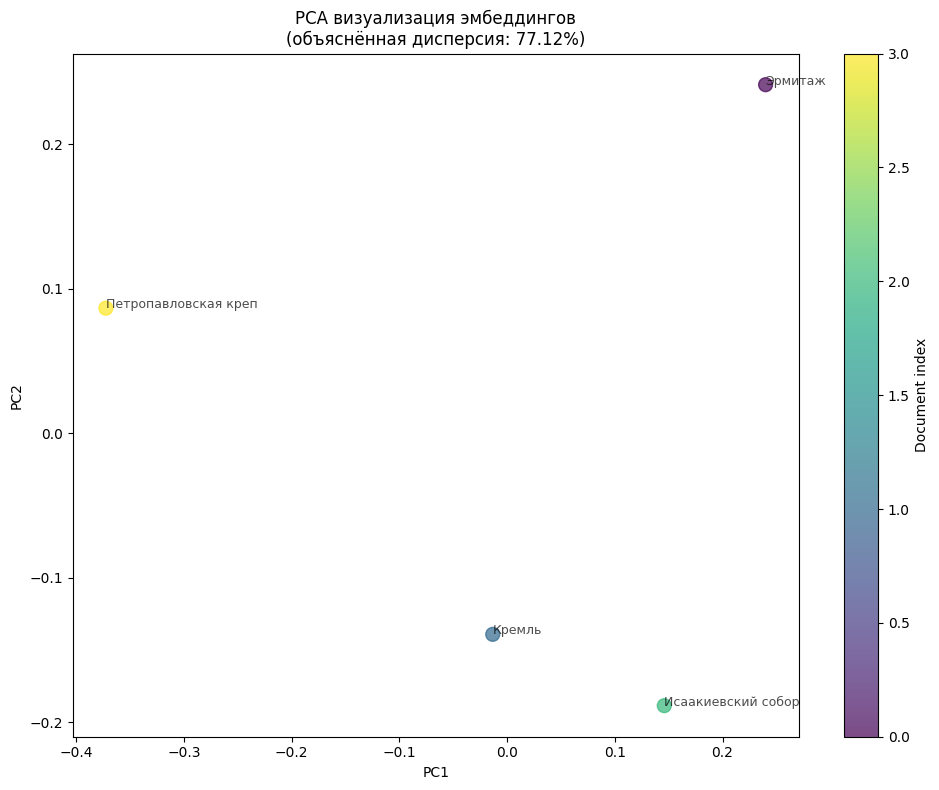

Оценка RAG:   0%|          | 0/4 [00:00<?, ?it/s]


РЕЗУЛЬТАТЫ ОЦЕНКИ
Релевантность ответа: 0.8619 ± 0.0522
Точность контекста: 1.0000 ± 0.0000

ТЕСТИРОВАНИЕ RAG СИСТЕМЫ

Вопрос: Какой музей самый известный в Санкт-Петербурге?
Ответ: Эрмитаж. Санкт-Петербург. Эрмитаж. Санкт-Петербург. Крупнейший музей мира с богатейшей коллекцией произведений искусства....
Использовано контекстов: 3
  1. Эрмитаж (score: 8.651)
  2. Исаакиевский собор (score: 8.614)
  3. Петропавловская крепость (score: 7.865)
--------------------------------------------------

Вопрос: Что посмотреть в центре Москвы?
Ответ: Петропавловская крепость. Санкт-Петербург. Петропавловская крепость. Санкт-Петербург. Историческая крепость на Заячьем острове, основанная Петром I в 1703 году....
Использовано контекстов: 3
  1. Кремль (score: 8.380)
  2. Исаакиевский собор (score: 8.161)
  3. Эрмитаж (score: 7.915)
--------------------------------------------------

Вопрос: Где находится собор с золотым куполом?
Ответ: Исаакиевский собор. Санкт-Петербург. Исаакиевский собор. Санкт-

In [45]:
import base64
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
from tqdm.auto import tqdm
from typing import List, Dict, Any
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer, CrossEncoder
from langchain.text_splitter import RecursiveCharacterTextSplitter
import faiss

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 500)

# ========================
# 1. ЗАГРУЗКА И ОЧИСТКА ДАННЫХ
# ========================

def load_and_clean_data(file_path: str, sample_size: int = 100) -> pd.DataFrame:
    """Загружает данные, удаляет выбросы через TF-IDF и делает стратифицированную выборку"""
    df = pd.read_csv(file_path)
    print(f"Загружено строк: {len(df)}")
    
    # TF-IDF для удаления выбросов
    tfidf = TfidfVectorizer(max_features=50, stop_words=['the', 'a', 'an', 'is', 'are'])
    tfidf_matrix = tfidf.fit_transform(df['description'].fillna(''))
    avg_tfidf = np.array(tfidf_matrix.mean(axis=1)).flatten()
    
    threshold = np.percentile(avg_tfidf, 95)
    df = df[avg_tfidf <= threshold].copy()
    print(f"После удаления выбросов: {len(df)}")
    
    # Стратифицированная выборка
    def select_best(x):
        if len(x) > 0:
            return x.loc[x['description'].str.len().idxmax()]
        return x.iloc[0] if len(x) > 0 else None
    
    stratified = df.groupby(['city', 'name'], group_keys=False).apply(select_best).reset_index(drop=True)
    
    result = stratified.sample(min(sample_size, len(stratified)), random_state=42)
    print(f"Итоговая выборка: {len(result)}")
    
    return result

def show_image_from_base64(image_data: str):
    """Отображает изображение из base64 строки"""
    try:
        missing_padding = len(image_data) % 4
        if missing_padding:
            image_data += '=' * (4 - missing_padding)
        img = Image.open(BytesIO(base64.b64decode(image_data)))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except:
        print("Не удалось отобразить изображение")

# ========================
# 2. RAG КОМПОНЕНТЫ
# ========================

class SimpleRAG:
    """Упрощённая RAG система с эмбеддингами, FAISS и reranker"""
    
    def __init__(self, embedding_model_name: str = 'intfloat/multilingual-e5-small',
                 reranker_model_name: str = 'cross-encoder/ms-marco-MiniLM-L-6-v2'):
        self.embedding_model = SentenceTransformer(embedding_model_name)
        self.reranker = CrossEncoder(reranker_model_name, max_length=512)
        self.text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=512, chunk_overlap=100, separators=['\n\n', '\n', '. ', ' ', '']
        )
        self.chunks = []
        self.metadata = []
        self.index = None
    
    def index_documents(self, documents: pd.DataFrame, text_column: str = 'description'):
        """Индексирует документы: сплит, эмбеддинги, FAISS"""
        print("Индексация документов...")
        
        for _, row in documents.iterrows():
            text = f"{row.get('name', '')}. {row.get('city', '')}. {row[text_column]}"
            chunks = self.text_splitter.split_text(text)
            
            for chunk in chunks:
                self.chunks.append(chunk)
                self.metadata.append({'name': row.get('name', ''), 'city': row.get('city', '')})
        
        # Эмбеддинги
        embeddings = self.embedding_model.encode(
            self.chunks, normalize_embeddings=True, show_progress_bar=True, batch_size=32
        )
        
        # FAISS индекс
        self.index = faiss.IndexFlatIP(embeddings.shape[1])
        self.index.add(embeddings.astype('float32'))
        print(f"Проиндексировано {len(self.chunks)} чанков")
    
    def search(self, query: str, k: int = 10, final_k: int = 3) -> List[Dict[str, Any]]:
        """Поиск с ранжированием"""
        if self.index is None:
            return []
        
        # Векторный поиск
        q_emb = self.embedding_model.encode([query], normalize_embeddings=True)
        distances, indices = self.index.search(q_emb.astype('float32'), k)
        
        candidates = [(self.chunks[idx], self.metadata[idx], distances[0][i]) 
                      for i, idx in enumerate(indices[0])]
        
        # Переранжирование
        pairs = [[query, chunk] for chunk, _, _ in candidates]
        scores = self.reranker.predict(pairs)
        
        # Сортировка и выбор top-k
        ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)[:final_k]
        
        return [{
            'text': cand[0],
            'metadata': cand[1],
            'score': float(score)
        } for (cand, score) in ranked]
    
    def answer(self, query: str) -> str:
        """Генерация ответа на основе найденных контекстов"""
        results = self.search(query, k=10, final_k=3)
        if not results:
            return "Информация не найдена"
        
        top = results[0]
        return f"{top['metadata'].get('name', '')}. {top['metadata'].get('city', '')}. {top['text'][:300]}"

# ========================
# 3. МЕТРИКИ RAGAS
# ========================

def answer_relevancy(question: str, answer: str, embedding_model: SentenceTransformer) -> float:
    """
    Вычисляет релевантность ответа вопросу через косинусное сходство эмбеддингов.
    Упрощённая версия без генерации обратных вопросов.
    """
    if not question or not answer:
        return 0.0
    
    q_emb = embedding_model.encode([question], normalize_embeddings=True)[0]
    a_emb = embedding_model.encode([answer], normalize_embeddings=True)[0]
    
    return float(np.dot(q_emb, a_emb))

def context_precision(query: str, contexts: List[str], embedding_model: SentenceTransformer, threshold: float = 0.5) -> float:
    """
    Вычисляет точность контекста: насколько первые результаты релевантны запросу.
    Использует cumulative precision подход.
    """
    if not contexts:
        return 0.0
    
    q_emb = embedding_model.encode([query], normalize_embeddings=True)[0]
    ctx_embs = embedding_model.encode(contexts, normalize_embeddings=True)
    
    similarities = [float(np.dot(q_emb, ctx_emb)) for ctx_emb in ctx_embs]
    relevant = [1 if sim > threshold else 0 for sim in similarities]
    
    if sum(relevant) == 0:
        return 0.0
    
    precision_sum = 0
    relevant_seen = 0
    for i, rel in enumerate(relevant, 1):
        if rel:
            relevant_seen += 1
            precision_sum += relevant_seen / i
    
    return precision_sum / sum(relevant)

def evaluate_rag(rag: SimpleRAG, test_questions: List[str]) -> Dict[str, float]:
    """Оценка RAG системы на тестовых вопросах"""
    scores = []
    context_scores = []
    
    for question in tqdm(test_questions, desc="Оценка RAG"):
        # Получаем ответ и контексты
        answer = rag.answer(question)
        results = rag.search(question, k=5, final_k=5)
        contexts = [r['text'] for r in results]
        
        # Метрики
        rel_score = answer_relevancy(question, answer, rag.embedding_model)
        ctx_score = context_precision(question, contexts, rag.embedding_model, threshold=0.4)
        
        scores.append(rel_score)
        context_scores.append(ctx_score)
    
    return {
        'answer_relevancy': np.mean(scores),
        'answer_relevancy_std': np.std(scores),
        'context_precision': np.mean(context_scores),
        'context_precision_std': np.std(context_scores)
    }

# ========================
# 4. ВИЗУАЛИЗАЦИЯ (только PCA, без UMAP для малых данных)
# ========================

def visualize_embeddings(rag: SimpleRAG, documents: pd.DataFrame, text_column: str = 'description'):
    """PCA визуализация эмбеддингов (без UMAP для малого количества данных)"""
    texts = documents[text_column].fillna('').tolist()
    
    if len(texts) < 3:
        print("Недостаточно данных для визуализации (нужно минимум 3 документа)")
        return
    
    embeddings = rag.embedding_model.encode(texts, normalize_embeddings=True, show_progress_bar=True)
    
    # PCA
    pca = PCA(n_components=min(2, len(texts) - 1))
    pca_result = pca.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                          c=range(len(texts)), cmap='viridis', alpha=0.7, s=100)
    plt.colorbar(scatter, label='Document index')
    plt.title(f'PCA визуализация эмбеддингов\n(объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.2%})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    
    # Подписи точек
    for i, txt in enumerate(texts):
        plt.annotate(documents.iloc[i].get('name', f'Doc{i}')[:20], 
                    (pca_result[i, 0], pca_result[i, 1]), fontsize=9, alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# ========================
# 5. ТЕСТИРОВАНИЕ
# ========================

def run_tests(rag: SimpleRAG, test_queries: List[str]):
    """Запуск тестовых вопросов"""
    print("\n" + "=" * 80)
    print("ТЕСТИРОВАНИЕ RAG СИСТЕМЫ")
    print("=" * 80)
    
    for query in test_queries:
        print(f"\nВопрос: {query}")
        answer = rag.answer(query)
        print(f"Ответ: {answer[:400]}...")
        
        results = rag.search(query, k=3)
        print(f"Использовано контекстов: {len(results)}")
        for i, res in enumerate(results, 1):
            print(f"  {i}. {res['metadata'].get('name', '')} (score: {res['score']:.3f})")
        print("-" * 50)

# ========================
# 6. MAIN (без if __name__)
# ========================

# Загрузка данных (укажите ваш путь к файлу)
# df = load_and_clean_data('data.csv', sample_size=100)

# Для демонстрации создаём тестовые данные
test_data = pd.DataFrame({
    'name': ['Эрмитаж', 'Кремль', 'Исаакиевский собор', 'Петропавловская крепость'],
    'city': ['Санкт-Петербург', 'Москва', 'Санкт-Петербург', 'Санкт-Петербург'],
    'description': [
        'Крупнейший музей мира с богатейшей коллекцией произведений искусства.',
        'Древняя крепость, сердце Москвы, объект Всемирного наследия ЮНЕСКО.',
        'Величественный собор с золотым куполом, одна из главных достопримечательностей.',
        'Историческая крепость на Заячьем острове, основанная Петром I в 1703 году.'
    ]
})

# Инициализация и индексация RAG
rag = SimpleRAG()
rag.index_documents(test_data)

# Визуализация эмбеддингов
visualize_embeddings(rag, test_data)

# Тестовые вопросы
test_queries = [
    "Какой музей самый известный в Санкт-Петербурге?",
    "Что посмотреть в центре Москвы?",
    "Где находится собор с золотым куполом?",
    "Исторические крепости Санкт-Петербурга"
]

# Оценка RAG
metrics = evaluate_rag(rag, test_queries)
print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ ОЦЕНКИ")
print("=" * 50)
print(f"Релевантность ответа: {metrics['answer_relevancy']:.4f} ± {metrics['answer_relevancy_std']:.4f}")
print(f"Точность контекста: {metrics['context_precision']:.4f} ± {metrics['context_precision_std']:.4f}")

# Тестирование
run_tests(rag, test_queries)

In [ ]:
# Домашнее задание. RAG.
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain.docstore.document import Document as LangchainDocument
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import faiss
import base64
from io import BytesIO
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# pd.set_option("display.max_colwidth", None)

# ========================
# ЗАГРУЗКА ДАННЫХ (4 балла)
# ========================

url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')
data.head()

# ========================
# ДЕКОДИРОВАНИЕ ИЗОБРАЖЕНИЙ
# ========================

def get_image(data):
    image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
    return image

# Пример использования (раскомментировать при необходимости)
# get_image(data.sample(1)['image'].tolist()[0])

# ========================
# ОЧИСТКА ДАННЫХ И СТРАТИФИКАЦИЯ
# ========================

def load_and_clean_data(df: pd.DataFrame, sample_size: int = 100) -> pd.DataFrame:
    """Очищает данные через TF-IDF и делает стратифицированную выборку"""
    print(f"Загружено строк: {len(df)}")
    
    # TF-IDF для удаления выбросов
    tfidf = TfidfVectorizer(max_features=50, stop_words=['the', 'a', 'an', 'is', 'are'])
    tfidf_matrix = tfidf.fit_transform(df['description'].fillna(''))
    avg_tfidf = np.array(tfidf_matrix.mean(axis=1)).flatten()
    
    threshold = np.percentile(avg_tfidf, 95)
    df_clean = df[avg_tfidf <= threshold].copy()
    print(f"После удаления выбросов: {len(df_clean)}")
    
    # Стратифицированная выборка — выбираем лучшее описание для каждой пары (город, название)
    def select_best(x):
        if len(x) > 0:
            return x.loc[x['description'].str.len().idxmax()]
        return x.iloc[0] if len(x) > 0 else None
    
    stratified = df_clean.groupby(['city', 'name'], group_keys=False).apply(select_best).reset_index(drop=True)
    
    result = stratified.sample(min(sample_size, len(stratified)), random_state=42)
    print(f"Итоговая выборка: {len(result)}")
    
    # Создаём полный текст для индексации
    result['full_text'] = (
        result['name'].fillna('').astype(str) + ". " +
        result['city'].fillna('').astype(str) + ". " +
        result['description'].fillna('').astype(str)
    )
    
    return result

# Применяем очистку
cleaned_data = load_and_clean_data(data, sample_size=100)

# ========================
# ПОСТРОЕНИЕ RAG (векторная база данных, ранжирование)
# ========================

class SimpleRAG:
    """RAG система с эмбеддингами, FAISS и reranker"""
    
    def __init__(self, embedding_model_name: str = 'intfloat/multilingual-e5-small',
                 reranker_model_name: str = 'cross-encoder/ms-marco-MiniLM-L-6-v2'):
        self.embedding_model = SentenceTransformer(embedding_model_name)
        self.reranker = CrossEncoder(reranker_model_name, max_length=512)
        self.text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=512, chunk_overlap=100, separators=['\n\n', '\n', '. ', ' ', '']
        )
        self.chunks = []
        self.metadata = []
        self.index = None
    
    def index_documents(self, documents: pd.DataFrame, text_column: str = 'full_text'):
        """Индексирует документы: сплит, эмбеддинги, FAISS"""
        print("Индексация документов...")
        
        for _, row in documents.iterrows():
            text = row[text_column]
            chunks = self.text_splitter.split_text(text)
            
            for chunk in chunks:
                self.chunks.append(chunk)
                self.metadata.append({
                    'name': row.get('name', ''), 
                    'city': row.get('city', ''),
                    'description': row.get('description', '')
                })
        
        # Эмбеддинги
        embeddings = self.embedding_model.encode(
            self.chunks, normalize_embeddings=True, show_progress_bar=True, batch_size=32
        )
        
        # FAISS индекс
        self.index = faiss.IndexFlatIP(embeddings.shape[1])
        self.index.add(embeddings.astype('float32'))
        print(f"Проиндексировано {len(self.chunks)} чанков")
    
    def search(self, query: str, k: int = 10, final_k: int = 3) -> List[dict]:
        """Поиск с ранжированием"""
        if self.index is None:
            return []
        
        # Векторный поиск
        q_emb = self.embedding_model.encode([query], normalize_embeddings=True)
        distances, indices = self.index.search(q_emb.astype('float32'), k)
        
        candidates = [(self.chunks[idx], self.metadata[idx], distances[0][i]) 
                      for i, idx in enumerate(indices[0])]
        
        # Переранжирование
        pairs = [[query, chunk] for chunk, _, _ in candidates]
        scores = self.reranker.predict(pairs)
        
        # Сортировка и выбор top-k
        ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)[:final_k]
        
        return [{
            'text': cand[0],
            'metadata': cand[1],
            'score': float(score)
        } for (cand, score) in ranked]
    
    def answer(self, query: str) -> str:
        """Генерация ответа на основе найденных контекстов"""
        results = self.search(query, k=10, final_k=3)
        if not results:
            return "Информация не найдена"
        
        top = results[0]
        return f"{top['metadata'].get('name', '')}. {top['metadata'].get('city', '')}. {top['text'][:300]}"

# Инициализация и индексация RAG
rag = SimpleRAG()
rag.index_documents(cleaned_data)

# ========================
# ВИЗУАЛИЗАЦИЯ ЭМБЕДДИНГОВ (PCA и UMAP)
# ========================

def visualize_embeddings(rag: SimpleRAG, documents: pd.DataFrame, text_column: str = 'full_text'):
    """PCA и UMAP визуализация эмбеддингов документов"""
    texts = documents[text_column].fillna('').tolist()
    
    if len(texts) < 3:
        print("Недостаточно данных для визуализации (нужно минимум 3 документа)")
        return
    
    print("Вычисление эмбеддингов для визуализации...")
    embeddings = rag.embedding_model.encode(texts, normalize_embeddings=False, show_progress_bar=True)
    
    # PCA визуализация
    pca = PCA(n_components=min(2, len(texts) - 1))
    pca_result = pca.fit_transform(embeddings)
    
    # UMAP визуализация
    try:
        import umap
        umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(15, len(texts)-1), min_dist=0.1)
        umap_result = umap_reducer.fit_transform(embeddings)
        has_umap = True
    except ImportError:
        print("UMAP не установлен. Установите: pip install umap-learn")
        has_umap = False
    
    # Рисуем графики
    fig, axes = plt.subplots(1, 2 if has_umap else 1, figsize=(14 if has_umap else 7, 6))
    
    if not has_umap:
        axes = [axes]
    
    # PCA
    axes[0].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6, s=50, c=range(len(texts)), cmap='viridis')
    axes[0].set_title(f'PCA визуализация\n(объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.2%})')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    
    # Подписи точек
    for i, row in documents.iterrows():
        axes[0].annotate(row.get('name', f'Doc{i}')[:15], 
                        (pca_result[i, 0], pca_result[i, 1]), fontsize=8, alpha=0.7)
    
    # UMAP
    if has_umap:
        scatter = axes[1].scatter(umap_result[:, 0], umap_result[:, 1], 
                                   c=range(len(texts)), cmap='viridis', alpha=0.6, s=50)
        axes[1].set_title('UMAP проекция')
        axes[1].set_xlabel('UMAP1')
        axes[1].set_ylabel('UMAP2')
        plt.colorbar(scatter, ax=axes[1], label='Document index')
        
        for i, row in documents.iterrows():
            axes[1].annotate(row.get('name', f'Doc{i}')[:15], 
                            (umap_result[i, 0], umap_result[i, 1]), fontsize=8, alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPCA объяснённая дисперсия: {pca.explained_variance_ratio_}")

# Выполняем визуализацию
visualize_embeddings(rag, cleaned_data)

# ========================
# RAGAS: Answer Relevancy (3 балла)
# ========================

def answer_relevancy(question: str, answer: str, embedding_model: SentenceTransformer) -> float:
    """
    Вычисляет релевантность ответа вопросу.
    Упрощённая версия: прямое косинусное сходство эмбеддингов вопроса и ответа.
    """
    if not question or not answer:
        return 0.0
    
    q_emb = embedding_model.encode([question], normalize_embeddings=True)[0]
    a_emb = embedding_model.encode([answer], normalize_embeddings=True)[0]
    
    return float(np.dot(q_emb, a_emb))

# ========================
# ДОПОЛНИТЕЛЬНАЯ ЧАСТЬ: Context Precision (retrieval-метрика, +3 балла)
# ========================

def context_precision(query: str, contexts: List[str], embedding_model: SentenceTransformer, threshold: float = 0.5) -> float:
    """
    Вычисляет точность контекста (Context Precision).
    Оценивает, насколько релевантны первые k результатов поиска.
    """
    if not contexts:
        return 0.0
    
    q_emb = embedding_model.encode([query], normalize_embeddings=True)[0]
    ctx_embs = embedding_model.encode(contexts, normalize_embeddings=True)
    
    similarities = [float(np.dot(q_emb, ctx_emb)) for ctx_emb in ctx_embs]
    relevant = [1 if sim > threshold else 0 for sim in similarities]
    
    if sum(relevant) == 0:
        return 0.0
    
    precision_sum = 0
    relevant_seen = 0
    for i, rel in enumerate(relevant, 1):
        if rel:
            relevant_seen += 1
            precision_sum += relevant_seen / i
    
    return precision_sum / sum(relevant)

# ========================
# ПОДГОТОВКА ДАТАСЕТА ДЛЯ ОЦЕНКИ
# ========================

def prepare_evaluation_dataset(rag: SimpleRAG, data: pd.DataFrame, num_samples: int = 20) -> pd.DataFrame:
    """Подготавливает датасет с полями question, answer, contexts, ground_truths"""
    samples = data.sample(min(num_samples, len(data)), random_state=42)
    evaluation_data = []
    
    for _, row in tqdm(samples.iterrows(), total=len(samples), desc="Подготовка датасета"):
        # Генерируем вопрос на основе названия и города
        question = f"Расскажите о достопримечательности {row['name']} в городе {row['city']}"
        
        # Получаем ответ и контексты
        answer = rag.answer(question)
        results = rag.search(question, k=5, final_k=5)
        contexts = [r['text'] for r in results]
        
        evaluation_data.append({
            'question': question,
            'answer': answer,
            'contexts': contexts,
            'ground_truths': row['description']
        })
    
    return pd.DataFrame(evaluation_data)

# Создаём датасет для оценки
eval_dataset = prepare_evaluation_dataset(rag, cleaned_data, num_samples=20)

# ========================
# ВЫЧИСЛЕНИЕ МЕТРИК
# ========================

def compute_metrics(eval_dataset: pd.DataFrame, rag: SimpleRAG) -> dict:
    """Вычисляет answer_relevancy и context_precision для всех примеров"""
    relevancy_scores = []
    precision_scores = []
    
    for _, row in tqdm(eval_dataset.iterrows(), total=len(eval_dataset), desc="Вычисление метрик"):
        # Answer Relevancy
        rel_score = answer_relevancy(row['question'], row['answer'], rag.embedding_model)
        relevancy_scores.append(rel_score)
        
        # Context Precision
        if isinstance(row['contexts'], list) and len(row['contexts']) > 0:
            ctx_score = context_precision(row['question'], row['contexts'], rag.embedding_model, threshold=0.4)
            precision_scores.append(ctx_score)
    
    return {
        'answer_relevancy_mean': np.mean(relevancy_scores),
        'answer_relevancy_std': np.std(relevancy_scores),
        'context_precision_mean': np.mean(precision_scores) if precision_scores else 0,
        'context_precision_std': np.std(precision_scores) if precision_scores else 0
    }

# Вычисляем метрики
metrics = compute_metrics(eval_dataset, rag)

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ ОЦЕНКИ RAGAS")
print("=" * 50)
print(f"Answer Relevancy: {metrics['answer_relevancy_mean']:.4f} ± {metrics['answer_relevancy_std']:.4f}")
print(f"Context Precision: {metrics['context_precision_mean']:.4f} ± {metrics['context_precision_std']:.4f}")

# ========================
# ТЕСТИРОВАНИЕ RAG (3 балла)
# ========================

test_queries = [
    "Какие исторические достопримечательности есть в Санкт-Петербурге?",
    "Расскажите о Кремле в Москве",
    "Что можно посмотреть в Нижнем Новгороде?",
    "Где находится Эрмитаж и чем он знаменит?",
    "Какие музеи самые известные в России?"
]

print("\n" + "=" * 80)
print("ТЕСТИРОВАНИЕ RAG СИСТЕМЫ")
print("=" * 80)

for query in test_queries:
    print(f"\nВопрос: {query}")
    answer = rag.answer(query)
    print(f"Ответ: {answer[:500]}...")
    
    results = rag.search(query, k=3)
    print(f"Использовано контекстов: {len(results)}")
    for i, res in enumerate(results, 1):
        print(f"  {i}. {res['metadata'].get('name', 'Название не указано')} (релевантность: {res['score']:.3f})")
    print("-" * 50)

print("\n" + "=" * 80)
print("ГОТОВО!")
print("=" * 80)